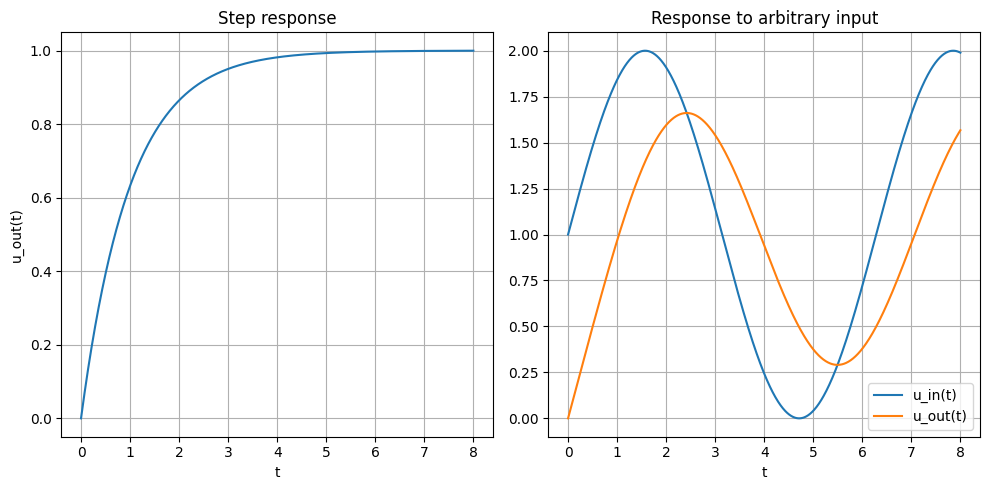

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# -----------------------------
# параметры RC-контура
# -----------------------------
R = 2.0        # Ом
C = 0.5        # Ф
tau = R * C    # постоянная времени RC

# -----------------------------
# передаточная функция
# G(s) = 1 / (RC*s + 1)
# -----------------------------
sys = signal.TransferFunction([1.0], [tau, 1.0])

# -----------------------------
# временная сетка
# -----------------------------
t = np.linspace(0, 8 * tau, 1000)

# -----------------------------
# 1) отклик на ступеньку (step response)
# -----------------------------
t_step, y_step = signal.step(sys, T=t)

# -----------------------------
# 2) отклик на произвольный вход (lsim)
# -----------------------------
u = np.sin(t) + 1.0   # пример входа
t_out, y_out, _ = signal.lsim(sys, U=u, T=t)

# -----------------------------
# графики
# -----------------------------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(t_step, y_step)
plt.title("Step response")
plt.xlabel("t")
plt.ylabel("u_out(t)")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(t, u, label="u_in(t)")
plt.plot(t_out, y_out, label="u_out(t)")
plt.title("Response to arbitrary input")
plt.xlabel("t")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

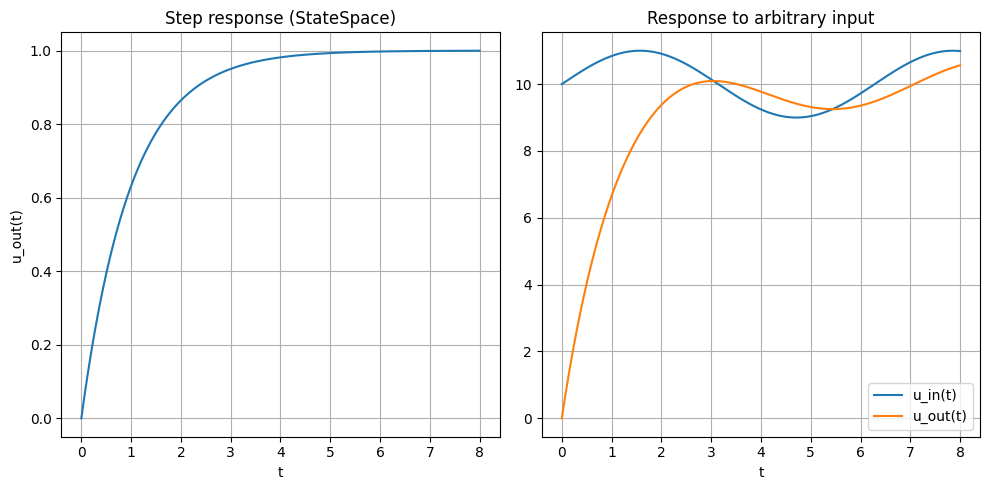

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# -----------------------------
# параметры RC-контура
# -----------------------------
R = 2.0        # Ом
C = 0.5        # Ф
tau = R * C

# -----------------------------
# модель в пространстве состояний
# -----------------------------
A = [[-1.0 / tau]]
B = [[ 1.0 / tau]]
C_mat = [[1.0]]
D = [[0.0]]

sys = signal.StateSpace(A, B, C_mat, D)

# -----------------------------
# временная сетка
# -----------------------------
t = np.linspace(0, 8 * tau, 1000)

# -----------------------------
# 1) отклик на ступеньку
# -----------------------------
t_step, y_step = signal.step(sys, T=t)

# -----------------------------
# 2) отклик на произвольный вход
# -----------------------------
u = np.sin(t) + 1.0
t_out, y_out, _ = signal.lsim(sys, U=u, T=t)

# -----------------------------
# графики
# -----------------------------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(t_step, y_step)
plt.title("Step response (StateSpace)")
plt.xlabel("t")
plt.ylabel("u_out(t)")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(t, u, label="u_in(t)")
plt.plot(t_out, y_out, label="u_out(t)")
plt.title("Response to arbitrary input")
plt.xlabel("t")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

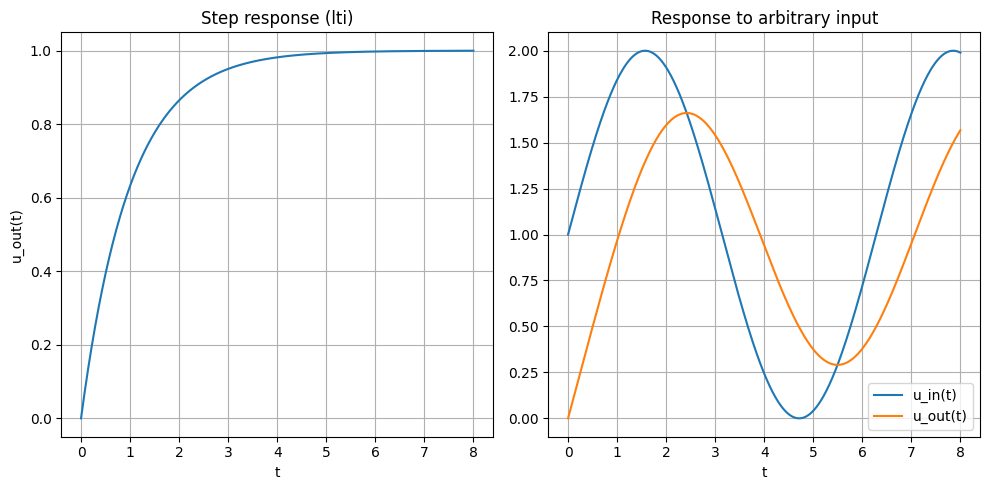

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# -----------------------------
# параметры RC-контура
# -----------------------------
R = 2.0
C = 0.5
tau = R * C

# -----------------------------
# LTI-система
# G(s) = 1 / (RC*s + 1)
# -----------------------------
sys = signal.lti([1.0], [tau, 1.0])

# -----------------------------
# временная сетка
# -----------------------------
t = np.linspace(0, 8 * tau, 1000)

# -----------------------------
# 1) отклик на ступеньку
# -----------------------------
t_step, y_step = signal.step(sys, T=t)

# -----------------------------
# 2) отклик на произвольный вход
# -----------------------------
u = np.sin(t) + 1.0
t_out, y_out, _ = signal.lsim(sys, U=u, T=t)

# -----------------------------
# графики
# -----------------------------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(t_step, y_step)
plt.title("Step response (lti)")
plt.xlabel("t")
plt.ylabel("u_out(t)")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(t, u, label="u_in(t)")
plt.plot(t_out, y_out, label="u_out(t)")
plt.title("Response to arbitrary input")
plt.xlabel("t")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

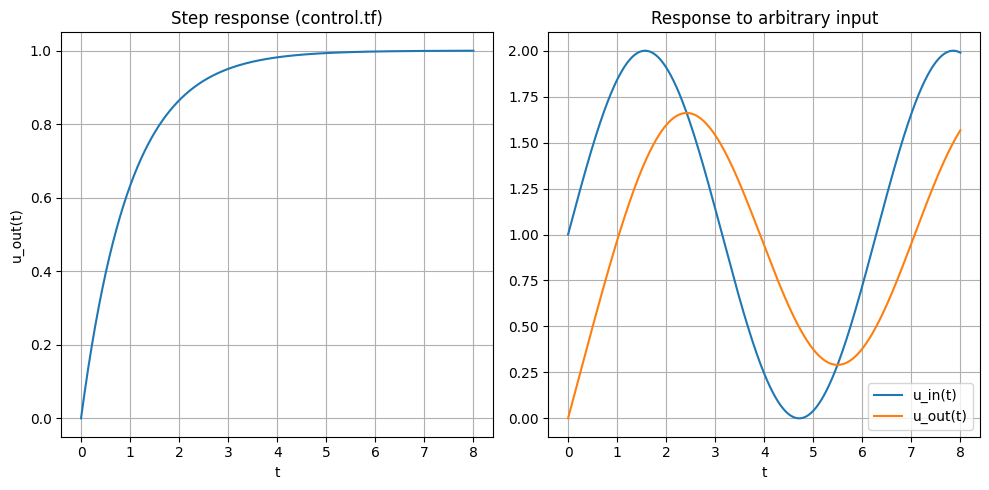

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

# -----------------------------
# параметры RC-контура
# -----------------------------
R = 2.0
C = 0.5
tau = R * C

# -----------------------------
# передаточная функция
# G(s) = 1 / (RC*s + 1)
# -----------------------------
G = ct.tf([1.0], [tau, 1.0])

# -----------------------------
# временная сетка
# -----------------------------
t = np.linspace(0, 8 * tau, 1000)

# -----------------------------
# 1) отклик на ступеньку
# -----------------------------
t_step, y_step = ct.step_response(G, T=t)

# -----------------------------
# 2) отклик на произвольный вход
# -----------------------------
u = np.sin(t) + 1.0
resp = ct.forced_response(G, T=t, U=u)

t_out = resp.time
y_out = resp.outputs

# -----------------------------
# графики
# -----------------------------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(t_step, y_step)
plt.title("Step response (control.tf)")
plt.xlabel("t")
plt.ylabel("u_out(t)")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(t, u, label="u_in(t)")
plt.plot(t_out, y_out, label="u_out(t)")
plt.title("Response to arbitrary input")
plt.xlabel("t")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

G1(s) = <TransferFunction>: sys[21]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = None

  5
  -
  1
G2(s) = <TransferFunction>: sys[22]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      1
  ----------
  0.01 s + 1
G(s)  = <TransferFunction>: sys[23]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      5
  ----------
  0.01 s + 1


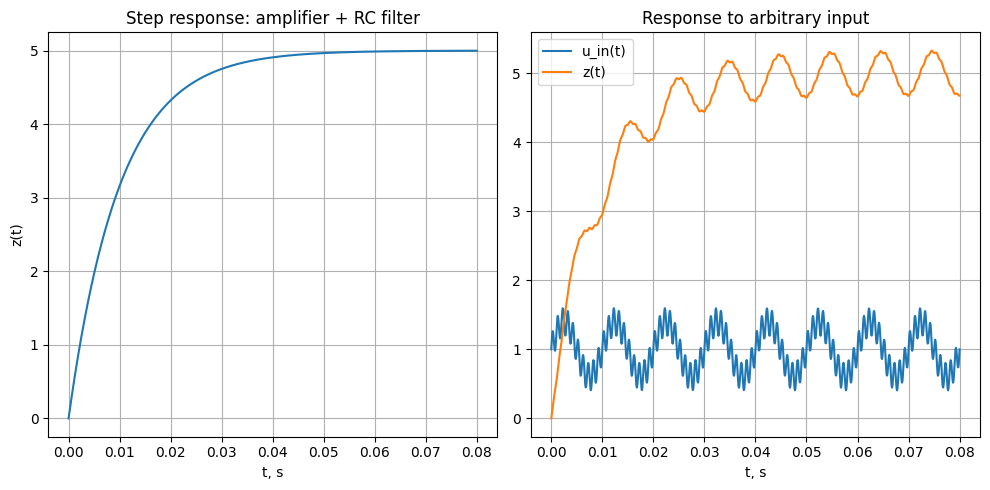

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

# -----------------------------
# параметры физической системы
# -----------------------------
K = 5.0         # коэффициент усиления усилителя
R = 10_000.0    # Ом
C = 1e-6        # Ф
tau = R * C     # постоянная времени RC

# -----------------------------
# звенья системы
# -----------------------------
# G1(s) = K
G1 = ct.tf([K], [1])

# G2(s) = 1 / (RC*s + 1)
G2 = ct.tf([1], [tau, 1])

# последовательное соединение
G = ct.series(G1, G2)
# эквивалентно можно написать: G = G1 * G2

print("G1(s) =", G1)
print("G2(s) =", G2)
print("G(s)  =", G)

# -----------------------------
# временная сетка
# -----------------------------
t = np.linspace(0, 0.08, 1000)

# -----------------------------
# 1) отклик на ступеньку
# -----------------------------
t_step, y_step = ct.step_response(G, T=t)

# -----------------------------
# 2) отклик на произвольный вход
# -----------------------------
u = 1.0 + 0.4 * np.sin(2 * np.pi * 100 * t) + 0.2 * np.sin(2 * np.pi * 1000 * t)

resp = ct.forced_response(G, T=t, U=u)
t_out = resp.time
y_out = resp.outputs

# -----------------------------
# графики
# -----------------------------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(t_step, y_step)
plt.title("Step response: amplifier + RC filter")
plt.xlabel("t, s")
plt.ylabel("z(t)")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(t, u, label="u_in(t)")
plt.plot(t_out, y_out, label="z(t)")
plt.title("Response to arbitrary input")
plt.xlabel("t, s")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Пример из текста методички

RC-контур как фильтр нижних частот: $R = 10\,000$ Ом, $C = 10^{-6}$ Ф ($\tau = 0.01$ с). На вход подаётся сумма постоянной составляющей и гармоник 100 Гц и 1000 Гц.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

R, C = 10_000.0, 1e-6
tau = R * C
G = ct.tf([1.0], [tau, 1.0])

t = np.linspace(0, 0.08, 4000)
u = 1.0 + 0.4 * np.sin(2 * np.pi * 100 * t) + 0.2 * np.sin(2 * np.pi * 1000 * t)
t_out, y_out = ct.forced_response(G, T=t, U=u)

# коэффициенты передачи на частотах гармоник
for f in (100, 1000):
    print(f"|W(i*2*pi*{f})| =", abs(G(2j * np.pi * f)))

plt.figure(figsize=(9, 4))
plt.plot(t, u, label='u(t)', alpha=0.6)
plt.plot(t_out, y_out, label='u_C(t)')
plt.xlabel('t, с')
plt.legend()
plt.grid()
plt.show()

### Пример из текста методички

Последовательное соединение: усилитель $G_1(s) = K$ и RC-фильтр $G_2(s) = 1/(RCs+1)$. Усилитель не имеет состояний, поэтому в пространстве состояний он задаётся только матрицей $D_1 = K$. (Набор $A_1 = 0$, $B_1 = 1$, $C_1 = K$ задал бы интегратор $K/s$.)

In [ ]:
from scipy import signal

K = 2.0
R, C = 10_000.0, 1e-6
tau = R * C

# блок 2 (RC-фильтр)
A2 = [[-1 / tau]]
B2 = [[1 / tau]]
C2 = [[1]]
D2 = [[0]]

t = np.linspace(0, 0.1, 1000)
u_in = np.ones_like(t)

# control: усилитель без состояний
G1 = ct.ss([], [], [], [[K]])
G2 = ct.ss(A2, B2, C2, D2)
G = ct.series(G1, G2)
t_ct, y_ct = ct.forced_response(G, T=t, U=u_in)

# scipy.signal: соединение через передаточные функции
num2, den2 = signal.ss2tf(A2, B2, C2, D2)
sys = signal.TransferFunction(np.polymul([K], num2[0]), den2)
t_sig, y_sig, _ = signal.lsim(sys, U=u_in, T=t)

print("полюса:", G.poles(), " статический коэффициент:", ct.dcgain(G))

plt.plot(t, u_in, '--', label='u(t)')
plt.plot(t_ct, y_ct, label='y(t), control')
plt.plot(t_sig, y_sig, ':', label='y(t), scipy.signal')
plt.legend()
plt.grid()
plt.show()

### Пример из текста методички

Параллельное соединение: $G_1(s) = K$ и $G_2(s) = 1/(R_2 C s + 1)$.

In [ ]:
K = 2.0
R2, C = 10_000.0, 1e-6
tau = R2 * C

# control
G1 = ct.ss([], [], [], [[K]])
G2 = ct.ss([[-1 / tau]], [[1 / tau]], [[1]], [[0]])
G = ct.parallel(G1, G2)

# scipy.signal: состояние общее с G2, выходы складываются: D = D1 + D2
sys = signal.StateSpace([[-1 / tau]], [[1 / tau]], [[1]], [[K + 0.0]])

t = np.linspace(0, 0.1, 1000)
u_in = np.ones_like(t)
t_ct, y_ct = ct.forced_response(G, T=t, U=u_in)
t_sig, y_sig, _ = signal.lsim(sys, U=u_in, T=t)

plt.plot(t, u_in, '--', label='u(t)')
plt.plot(t_ct, y_ct, label='y(t), control')
plt.plot(t_sig, y_sig, ':', label='y(t), scipy.signal')
plt.legend()
plt.grid()
plt.show()